**Problem 6**

The number of awards earned by students at one high school. Predictors of the number of awards earned include the type of program in which the student was enrolled (e.g., vocational, general, or academic) and the score on their final exam in math. The dataset is taken from:

UCLA Poisson Dataset

Fit the Poisson generalized linear model (GLM) to identify the factors associated with the number of awards earned by students at one high school. Interpret the results.

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

In [2]:
#load dataset
url = "https://stats.idre.ucla.edu/stat/data/poisson_sim.csv"

df = pd.read_csv(url)

In [3]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          200 non-null    int64
 1   num_awards  200 non-null    int64
 2   prog        200 non-null    int64
 3   math        200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [4]:
#Convert Program to Categorical
df['prog'] = df['prog'].astype('category')

In [5]:
#Exploratory Data Analysis
df.describe()

,id,num_awards,math
count,200.000000,200.000000,200.000000
mean,100.500000,0.630000,52.645000
std,57.879185,1.052921,9.368448
min,1.000000,0.000000,33.000000
25%,50.750000,0.000000,45.000000
50%,100.500000,0.000000,52.000000
75%,150.250000,1.000000,59.000000
max,200.000000,6.000000,75.000000


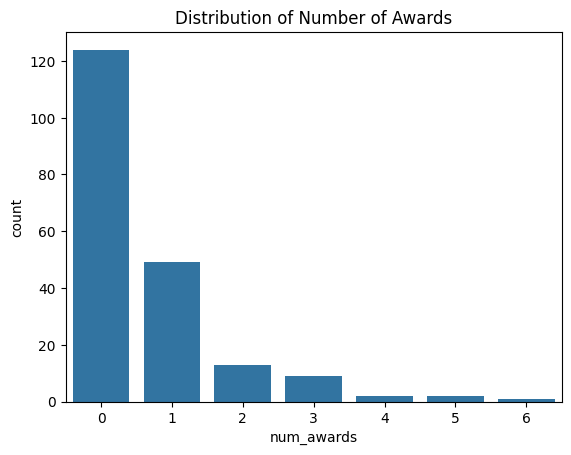

In [6]:
#Distribution of Awards
sns.countplot(x='num_awards', data=df)

plt.title("Distribution of Number of Awards")

plt.show()

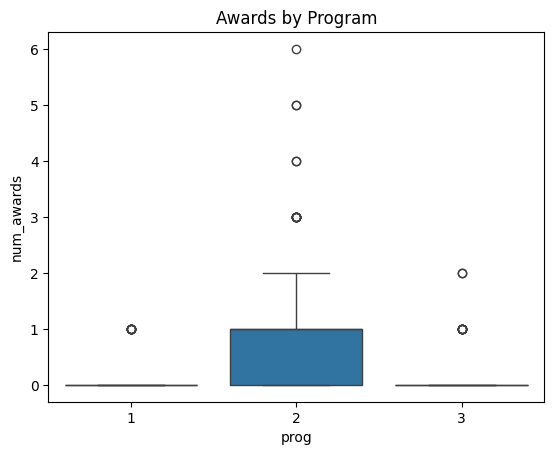

In [7]:
#Awards by Program
sns.boxplot(
    x='prog',
    y='num_awards',
    data=df
)

plt.title("Awards by Program")

plt.show()

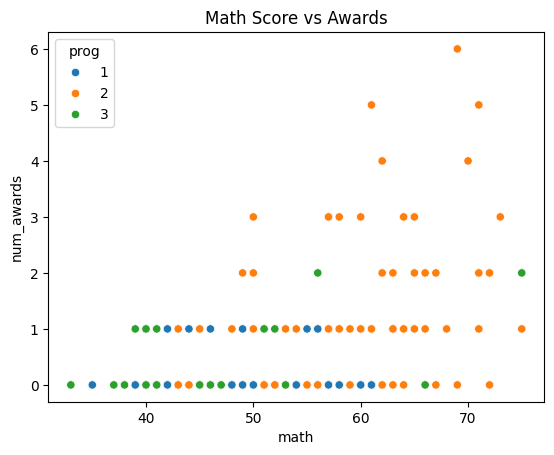

In [8]:
#Math Score vs Awards
sns.scatterplot(
    x='math',
    y='num_awards',
    hue='prog',
    data=df
)

plt.title("Math Score vs Awards")

plt.show()

In [9]:
#Fit Poisson Regression Model
model = smf.glm(
    formula='num_awards ~ prog + math',
    data=df,
    family=sm.families.Poisson()
).fit()

In [10]:
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             num_awards   No. Observations:                  200
Model:                            GLM   Df Residuals:                      196
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -182.75
Date:                Sun, 10 May 2026   Deviance:                       189.45
Time:                        11:54:01   Pearson chi2:                     212.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3881
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.2471      0.658     -7.969      0.0

**Interpretation of Poisson Regression Results**

The Poisson regression model examines how program type and math score affect the number of awards earned by students.

The overall model appears statistically meaningful, with a pseudo R² of 0.388, indicating that the predictors explain a reasonable portion of the variation in award counts.

**Interpretation of Predictors**

**Math Score**

Coefficient = 0.0702
p-value < 0.001

Math score is a statistically significant predictor.

A higher math score increases the expected number of awards earned by students.

**Program Type**

Reference category = Program 1

**Program 2**

Coefficient = 1.0839
p-value = 0.002

Program 2 is statistically significant.

Students in Program 2 are expected to earn more awards compared to students in Program 1.

**Program 3**

Coefficient = 0.3698
p-value = 0.402

Program 3 is not statistically significant because p > 0.05.

There is no strong evidence that Program 3 differs from Program 1 in the expected number of awards.

**Interpretation of Coefficients in Poisson Regression**

Since Poisson regression uses a log link:

log(μ)=β
0
	​

+β
1
	​

X
1
	​

+⋯

log(μ)=β
0
	​

+β
1
	​

X
1
	​

+⋯

Exponentiating coefficients gives Incident Rate Ratios (IRR).